# **Basic Image Manipulation**

So far we've learned how to read, display, and draw on images.

Now it's time to actually **modify** them.

In this notebook you'll learn how to:

- Crop images
- Resize images
- Scale images
- Preserve aspect ratio
- Choose the right interpolation method
- Rotate images
- Translate (move) images
- Flip images

These are some of the most common operations used in computer vision, image preprocessing, and deep learning pipelines.

---

## **1. Cropping Images**

Cropping means selecting only a portion of an image.

Unlike many OpenCV functions, cropping **does not use a special function**.

Since an image is just a NumPy array, we crop it using **array slicing**.

Syntax:

image[y1:y2, x1:x2]

Remember:

- rows = y
- columns = x

This is one of the most common mistakes beginners make.

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = cv2.imread(r"C:\Users\DELL\Desktop\resources\ComputerVision\Computer Vision\Computer Vision Sessions\vision-s-01\pic\002.jpg")

print("Shape: ", image.shape)

Shape:  (183, 275, 3)


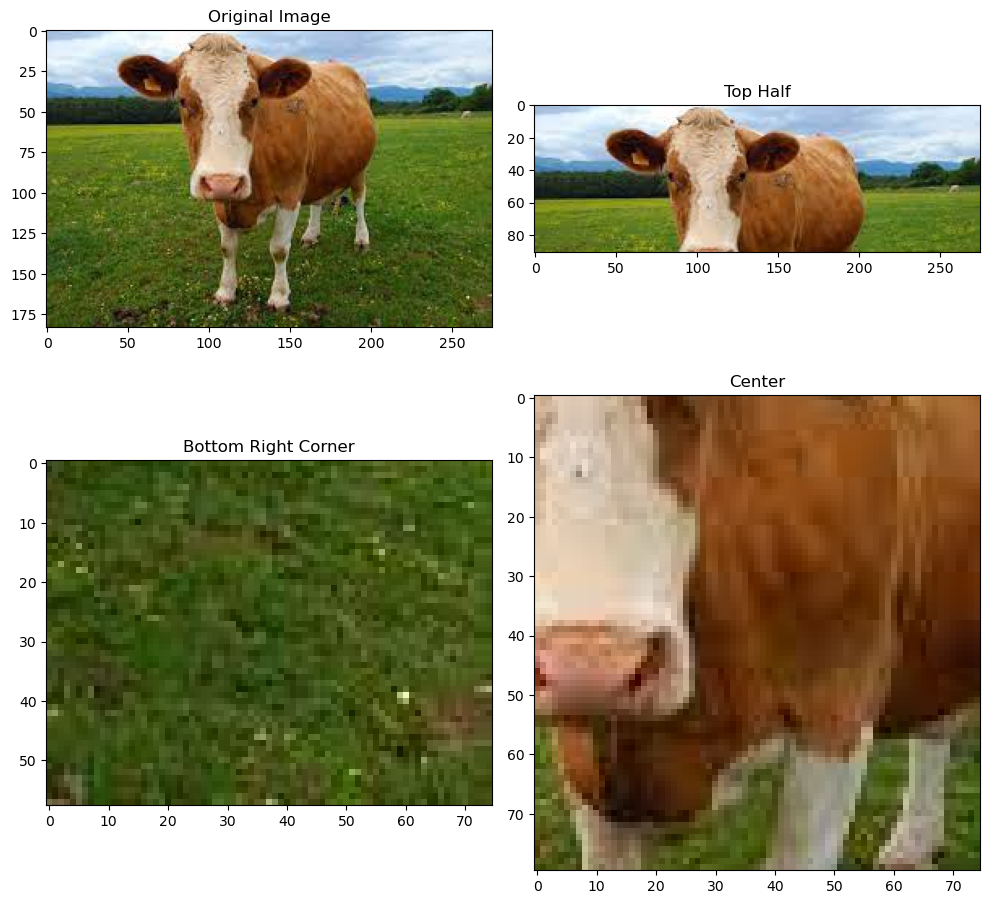

In [4]:
top_half_image = image[:91, :, :]
bottom_right_corner_image = image[125:, 200:, :]
center_image = image[50:130, 100:175, :]

plt.figure(figsize=(10, 10))

plt.subplot(221); plt.imshow(image[..., ::-1]); plt.title("Original Image")
plt.subplot(222); plt.imshow(top_half_image[..., ::-1]); plt.title("Top Half")
plt.subplot(223); plt.imshow(bottom_right_corner_image[..., ::-1]); plt.title("Bottom Right Corner")
plt.subplot(224); plt.imshow(center_image[..., ::-1]); plt.title("Center")


plt.tight_layout()
plt.show()

# **2. Resizing**

Resizing changes the dimensions of an image while keeping all of its content. You can either specify the **exact output size** or scale the image by a multiplication factor.

> **Resizing** scales the whole image to a new size, whereas **Cropping** keeps only a selected region of an image.

---
### **Syntax**

```python
cv2.resize(
    src,
    dsize,
    fx=0,
    fy=0,
    interpolation=cv2.INTER_LINEAR
)
```
---
### **Parameters**

| Parameter | Description |
|-----------|-------------|
| `src` | The input image to resize. |
| `dsize` | The desired output size as **`(width, height)`**. Set to `None` if using `fx` and `fy`. |
| `fx` | Horizontal scaling factor. `fx=2` doubles the width, `fx=0.5` halves it. |
| `fy` | Vertical scaling factor. `fy=2` doubles the height, `fy=0.5` halves it. |
| `interpolation` | Specifies how new pixel values are computed during resizing. The default is `cv2.INTER_LINEAR`. |

---

## **2.1 Resizing Using `dsize`**

Use the `dsize` parameter when you know the exact dimensions of the output image.

The output size must be provided as:

```python
(width, height)
```

> **Note:** `image.shape` returns `(height, width)`, but `dsize` expects `(width, height)`.

---

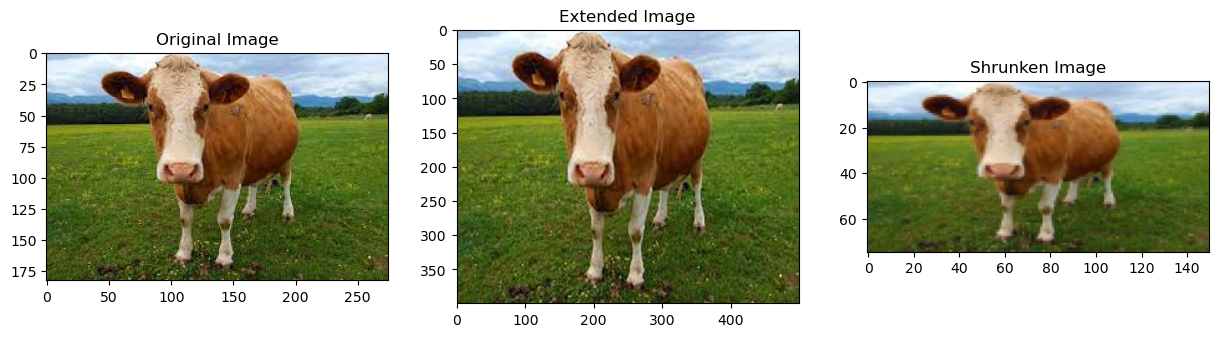

Original Image Shape:  (183, 275, 3)
Extended Image Shape: (400, 500, 3)
Shrunken Image Shape: (75, 150, 3)


In [14]:
extended_image = cv2.resize(image, dsize=(500, 400), interpolation=cv2.INTER_CUBIC)
shrunken_image = cv2.resize(image, dsize=(150, 75), interpolation=cv2.INTER_AREA)

plt.figure(figsize=(15, 5))
plt.subplot(131); plt.imshow(image[..., ::-1]); plt.title("Original Image")
plt.subplot(132); plt.imshow(extended_image[..., ::-1]); plt.title("Extended Image")
plt.subplot(133); plt.imshow(shrunken_image[..., ::-1]); plt.title("Shrunken Image")
plt.show()

print("Original Image Shape: ", image.shape)
print("Extended Image Shape:", extended_image.shape)
print("Shrunken Image Shape:", shrunken_image.shape)

> **Note:** `cv2.resize()` does **not** modify the original image. Instead, it returns a **new resized image**, so you should assign the result to a variable.

## **2.2 Scaling Using `fx` and `fy`**

Scaling is another way to resize an image. Instead of specifying the output dimensions, you specify how much the image should be enlarged or reduced.

- `fx` scales the image horizontally (width).
- `fy` scales the image vertically (height).

For example:

- `fx = fy = 2` doubles the image size.
- `fx = fy = 0.5` reduces the image size by half.

Use scaling when you want to resize an image by a percentage rather than an exact size.

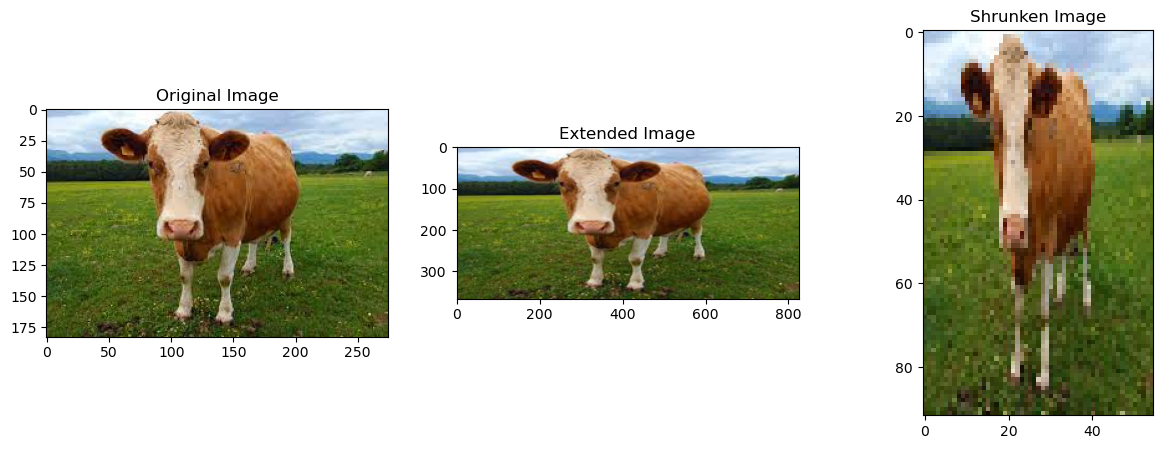

Original Image Shape:  (183, 275, 3)
Extended Image Shape: (366, 825, 3)
Shrunken Image Shape: (92, 55, 3)


In [17]:
extended_image = cv2.resize(image, None, fx=3, fy=2)
shrunken_image = cv2.resize(image, None, fx=0.2, fy=0.5)

plt.figure(figsize=(15, 5))
plt.subplot(131); plt.imshow(image[..., ::-1]); plt.title("Original Image")
plt.subplot(132); plt.imshow(extended_image[..., ::-1]); plt.title("Extended Image")
plt.subplot(133); plt.imshow(shrunken_image[..., ::-1]); plt.title("Shrunken Image")
plt.show()

print("Original Image Shape: ", image.shape)
print("Extended Image Shape:", extended_image.shape)
print("Shrunken Image Shape:", shrunken_image.shape)

## **2.3 Preserving the Aspect Ratio**

The **aspect ratio** is the relationship between an image's width and height.

When resizing, changing only one dimension or using different scaling factors may stretch or squash the image. To avoid distortion, preserve the original aspect ratio by scaling both dimensions proportionally.


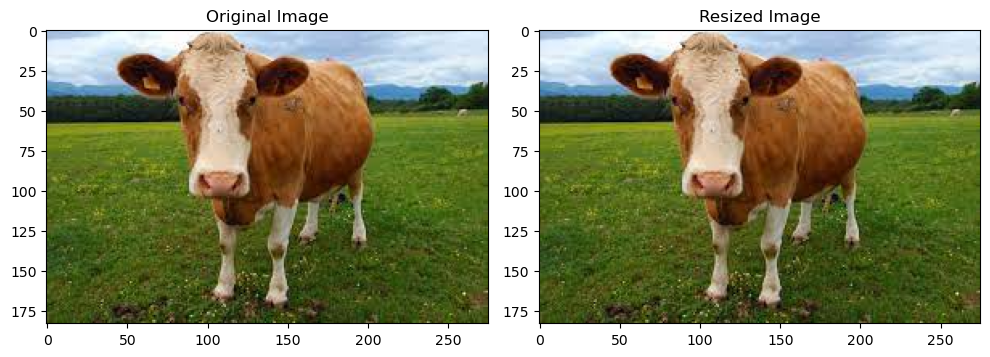

Original Image Shape:  (183, 275, 3)
Resized Image Shape: (183, 275, 3)


In [25]:
height, width = image.shape[:2]

new_width = 500
aspect_ratio = 500 / width
new_height = int(height * aspect_ratio)

resized_image = cv2.resize(image, (width, height))

plt.figure(figsize=(10, 5))
plt.subplot(121); plt.imshow(image[..., ::-1]); plt.title("Original Image")
plt.subplot(122); plt.imshow(resized_image[..., ::-1]); plt.title("Resized Image")
plt.tight_layout()
plt.show()

print("Original Image Shape: ", image.shape)
print("Resized Image Shape:", resized_image.shape)

## **2.4 Interpolation Methods**

When an image is resized, OpenCV must calculate new pixel values. The **interpolation method** determines how these new values are computed.

Different interpolation methods produce different levels of quality and speed.

| Method | Best For |
|---------|----------|
| `INTER_NEAREST` | Pixel art and segmentation masks |
| `INTER_LINEAR` | General-purpose resizing (default) |
| `INTER_CUBIC` | Enlarging images |
| `INTER_AREA` | Shrinking images |
| `INTER_LANCZOS4` | Highest-quality resizing |

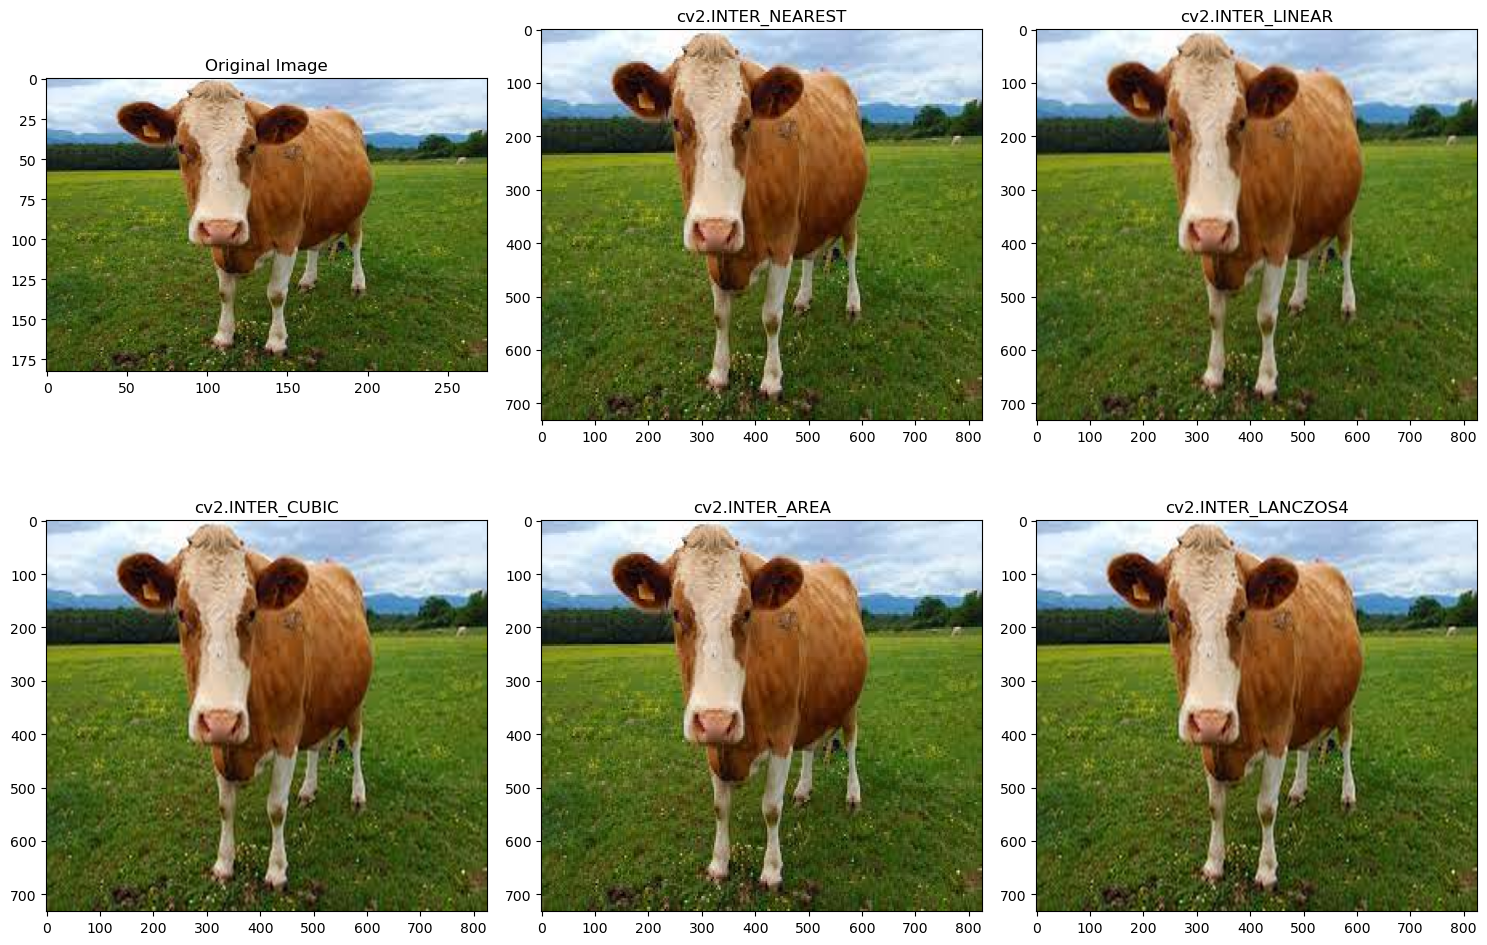

In [36]:
interpolations = {cv2.INTER_NEAREST : "cv2.INTER_NEAREST",
                  cv2.INTER_LINEAR :"cv2.INTER_LINEAR", 
                  cv2.INTER_CUBIC : "cv2.INTER_CUBIC",
                  cv2.INTER_AREA : "cv2.INTER_AREA",
                  cv2.INTER_LANCZOS4 : "cv2.INTER_LANCZOS4"}

plt.figure(figsize=(15, 10))
plt.subplot(231); plt.imshow(image[..., ::-1]); plt.title("Original Image")

for i, (interpolation, title) in zip(range(5), interpolations.items()):
    resized_image = cv2.resize(image, None, fx=3, fy=4, interpolation=interpolation)
    plt.subplot(232 + i); plt.imshow(resized_image[..., ::-1]); plt.title(title)

plt.tight_layout()
plt.show()

### Best Practices

- ✔ Use **`dsize`** when you know the exact output size.
- ✔ Use **`fx`** and **`fy`** to enlarge or shrink an image by a scale factor.
- ✔ Use `dsize=None` when specifying `fx` and `fy`.
- ✔ `INTER_AREA` is best for shrinking, while `INTER_CUBIC` or `INTER_LANCZOS4` are better for enlarging.


> **Note:** `cv2.resize()` returns a new resized image and leaves the original image unchanged.

---

# **3. Translation**

Translation is the process of **shifting an image from one position to another** without changing its size, shape, or orientation. Every pixel is moved by the same horizontal and vertical distance.

- Positive `tx` moves the image **right**.
- Negative `tx` moves the image **left**.
- Positive `ty` moves the image **down**.
- Negative `ty` moves the image **up**.

## **What is an Affine Transformation?**

An **affine transformation** is a geometric transformation that preserves **straight lines** and **parallelism**. It can change an image's **position**, **orientation**, **size**, or **shape**, depending on the transformation being applied.

Common affine transformations include:

- Translation (moves the image)
- Rotation (changes the orientation)
- Scaling (changes the size)
- Shearing (slants the shape)

Translation is the simplest affine transformation because it **only changes the image's position** while preserving its size, shape, and orientation.
## **How does OpenCV perform translation?**

OpenCV performs translation by applying a **2 × 3 transformation matrix** to every pixel in the image.

```text
[ 1  0  tx ]
[ 0  1  ty ]
```

where:

- `tx` is the horizontal shift.
- `ty` is the vertical shift.

The values `1` and `0` remain the same because the image is **not** being rotated, scaled, or sheared—only shifted. The only values that change are `tx` and `ty`, which determine how far the image moves.

Finally, the transformation matrix is applied using `cv2.warpAffine()`.

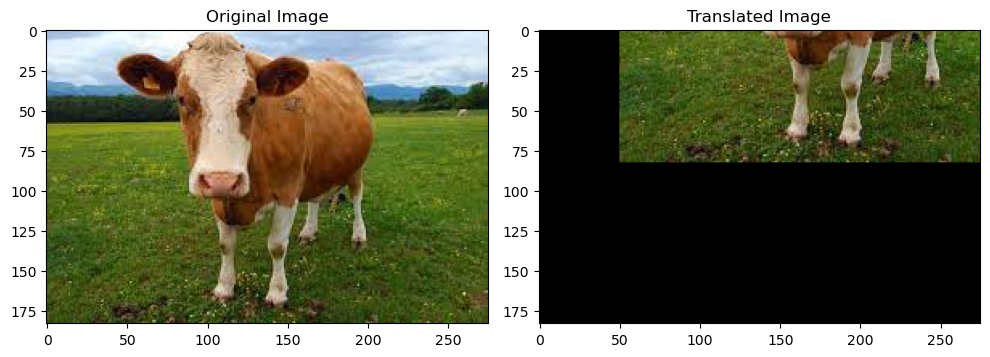

Original Image Shape:  (183, 275, 3)
Translated Image Shape:  (183, 275, 3)


In [5]:
height, width = image.shape[:2]
x, y = 50, -100
M = np.array([
    [1, 0, x],
    [0, 1, y]], np.float32)

translated_image = cv2.warpAffine(image, M, (width, height))

plt.figure(figsize=(10, 5))

plt.subplot(121); plt.imshow(image[..., ::-1]); plt.title("Original Image")
plt.subplot(122); plt.imshow(translated_image[..., ::-1]); plt.title("Translated Image")

plt.tight_layout()
plt.show()

print("Original Image Shape: ", image.shape)
print("Translated Image Shape: ", translated_image.shape)

> **Note:** The transformation matrix should have a floating-point data type (`np.float32` or `np.float64`), as required by `cv2.warpAffine()`. `np.float32` is commonly used because it is efficient and sufficient for most computer vision tasks.

# **4. Rotation**

Rotation is the process of **turning an image around a fixed point**, called the **center of rotation**. Unlike translation, rotation changes the image's orientation while preserving its shape and size.

## **Why do we use rotation?**

Rotation is commonly used for:

- Correcting image orientation.
- Data augmentation in machine learning and deep learning.
- Aligning images before further processing.
- Rotating objects to a desired angle for analysis.

---
## **How does OpenCV perform rotation?**

OpenCV performs rotation in **two steps**:

1. Create a **rotation matrix** using `cv2.getRotationMatrix2D()`.
2. Apply the rotation matrix to the image using `cv2.warpAffine()`.

### **Step 1 — Create the Rotation Matrix**

```python
M = cv2.getRotationMatrix2D(center, angle, scale)
```

| Parameter | Description |
|-----------|-------------|
| `center` | The point around which the image will be rotated, usually the image center. |
| `angle` | The rotation angle in degrees. Positive values rotate counterclockwise, while negative values rotate clockwise. |
| `scale` | Scales the image during rotation. `1` keeps the original size, values greater than `1` enlarge the image, and values less than `1` shrink it. |

---

### **Step 2 — Apply the Rotation**

```python
rotated = cv2.warpAffine(image, M, (width, height))
```

| Parameter | Description |
|-----------|-------------|
| `image` | The source image. |
| `M` | The 2 × 3 rotation matrix returned by `cv2.getRotationMatrix2D()`. |
| `(width, height)` | The size of the output image. |

> **Note:** `cv2.warpAffine()` returns a new rotated image and leaves the original image unchanged.

---
### **Best Practices**

- ✔ Rotate around the image center unless another pivot point is required.
- ✔ Use `scale=1` when you only want to rotate the image.
- ✔ Large rotation angles may cause parts of the image to be clipped if the output size remains unchanged.

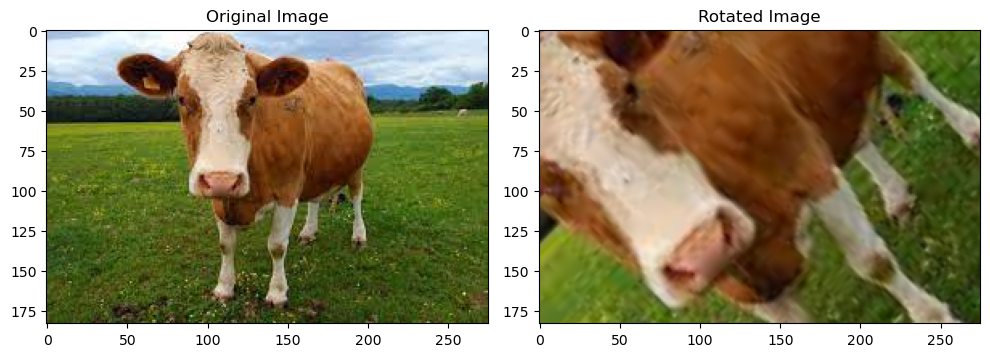

Original Image Shape:  (183, 275, 3)
Rotated Image Shape:  (183, 275, 3)


In [7]:
center = (width / 2, height / 2)
height, width = image.shape[:2]

M = cv2.getRotationMatrix2D(center, 45, 2)
rotated_image = cv2.warpAffine(image, M, (width, height))

plt.figure(figsize=(10, 5))

plt.subplot(121); plt.imshow(image[..., ::-1]); plt.title("Original Image")
plt.subplot(122); plt.imshow(rotated_image[..., ::-1]); plt.title("Rotated Image")

plt.tight_layout()
plt.show()

print("Original Image Shape: ", image.shape)
print("Rotated Image Shape: ", translated_image.shape)

# **5. Flipping**

Flipping mirrors an image.

Unlike rotation, no interpolation or transformation matrix is needed.

OpenCV provides `cv2.flip()`.

````python
horizontal = cv2.flip(image, 1)

vertical = cv2.flip(image, 0)

both = cv2.flip(image, -1)
````

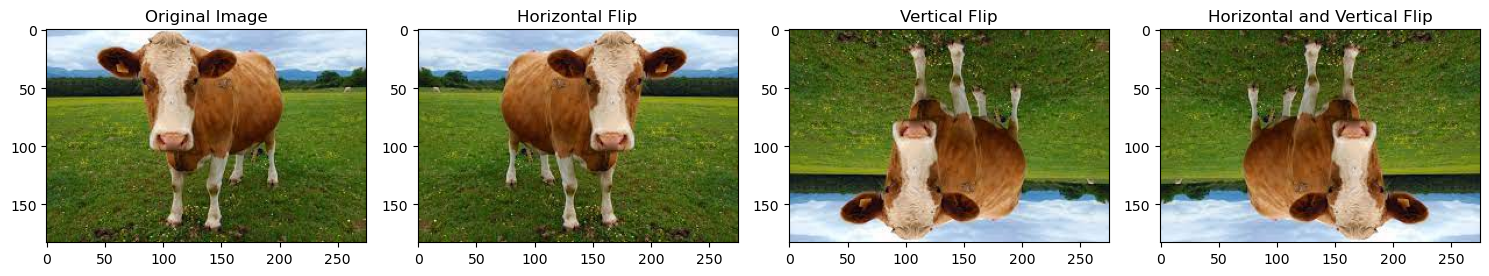

In [8]:
horizontal_flip = cv2.flip(image, 1)
vertical_flip = cv2.flip(image, 0)
horizontal_vertical_flip = cv2.flip(image, -1)

plt.figure(figsize=(15, 5))

plt.subplot(141); plt.imshow(image[..., ::-1]); plt.title("Original Image")
plt.subplot(142); plt.imshow(horizontal_flip[..., ::-1]); plt.title("Horizontal Flip")
plt.subplot(143); plt.imshow(vertical_flip[..., ::-1]); plt.title("Vertical Flip")
plt.subplot(144); plt.imshow(horizontal_vertical_flip[..., ::-1]); plt.title("Horizontal and Vertical Flip")

plt.tight_layout()
plt.show()

# **Mini Project**

Using only the techniques from this notebook:

1. Crop the center of an image.
2. Scale it to 150%.
3. Rotate it by 30°.
4. Translate it 50 pixels to the right.
5. Flip it horizontally.
6. Display every intermediate result in a single figure with titles.

# **Summary**
## **What You Learned**

✔ Access image dimensions with `image.shape`

✔ Crop using NumPy slicing

✔ Resize with `cv2.resize()`

✔ Scale with `fx` and `fy`

✔ Preserve aspect ratio to avoid distortion

✔ Choose the appropriate interpolation method

✔ Translate images with `cv2.warpAffine()`

✔ Rotate images using `cv2.getRotationMatrix2D()`

✔ Flip images with `cv2.flip()`

These operations are fundamental building blocks for image preprocessing, computer vision pipelines, and deep learning data augmentation.